# Logistic Regression Exercise

Now it's your turn to implement logistic regression on a new data set. For this purpose we use the Titanic Dataset. It includes personal information of all passengers on the Titanic as well as they survived the sinking of the Titanic or died.

Here’s the **Data Dictionary** of the dataset:

- PassengerID: type should be integers

- Survived: survived or not

- Pclass: class of Travel of every passenger

- Name: the name of the passenger

- Sex: gender

- Age: age of passengers

- SibSp: No. of siblings/spouse aboard

- Parch: No. of parent/child aboard

- Ticket: Ticket number

- Fare: what Prices they paid

- Cabin: cabin number

- Embarked: the port in which a passenger has embarked.

        - C: Cherbourg , S: Southampton , Q: Queenstown


You will find the data in the data folder (it's a zip folder, so you first have to unzip it).


## What you should do:

- conduct a brief EDA to become familiar with the data
- use Logistic Regression to predict if a passenger died or not

## How to do it:

Time is short, so aim for the simplest viable product first:
- Load the data

- Get a quick overview of the data

- Agree on a classification metric for the task 

- Create a simple heuristic/educated guess for the classification first. This is called a "baseline model". It is used to compare more complex models later (in this case: logistic regression). You as a data scientist want to prove how much your work/ML could improve the business metric, therefore you need a baseline model for comparison. In some cases you want to improve on an already existing model in your company which would be your baseline model then. In other cases, there are typical baseline models used in the specific field. For other tasks, you have to come up with a simple but meaningful idea, how to classify the data based on your business understanding (EDA). A baseline model should follow Occam’s Razor principle: "A simple model is the best model". 
    - Example of a baseline model: 
    If the task is to classify cats and dogs, a baseline model could be: We classify every animal as cat if its weight < 5 kg, otherwise the animal is classified as a dog. (The value of 5 kg is an educated guess, based on our business understanding/EDA.) 

- use one or two already numerical features to create a simple first model
    -  did it even beat your base model?

- Now you can go through the data science lifecycle again and again:
    - clean the data better

    - get more insights with EDA

    - add more features

    - do feature engineering 
    
    and check if your work improves your model further!

- Stop whenever time is up or you cannot improve your model any further.

The next notebook contains a solution to this problem. If you want to compare your final result with the result of this notebook, choose **25** as random seed and a test size of 30% for your train test split.

In [268]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score

In [269]:
%matplotlib inline
plt.rcParams['figure.figsize'] = 10, 8
sns.set_style('whitegrid')

In [270]:
# Import the dataset
titanic = pd.read_csv("data/titanic.csv")
titanic.columns
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [271]:
titanic.Survived.nunique(), titanic.Pclass.nunique(), titanic.Embarked.nunique(), titanic.Sex.nunique(), titanic.SibSp.nunique(), titanic.Parch.nunique()

(2, 3, 3, 2, 7, 7)

In [272]:
titanic['Survived'].unique(), titanic['Pclass'].unique(), titanic['Embarked'].unique(), titanic['Sex'].unique(), titanic['SibSp'].unique(), titanic['Parch'].unique()

(array([0, 1]),
 array([3, 1, 2]),
 array(['S', 'C', 'Q', nan], dtype=object),
 array(['male', 'female'], dtype=object),
 array([1, 0, 3, 4, 2, 5, 8]),
 array([0, 1, 2, 5, 3, 4, 6]))

In [274]:
# Missing values
titanic.isnull().sum()
print(f"missing values in data frame : {round(titanic.isna().sum().sum()/(titanic.shape[0]*titanic.shape[1])*100,2)} %")

missing values in data frame : 8.1 %


EDA

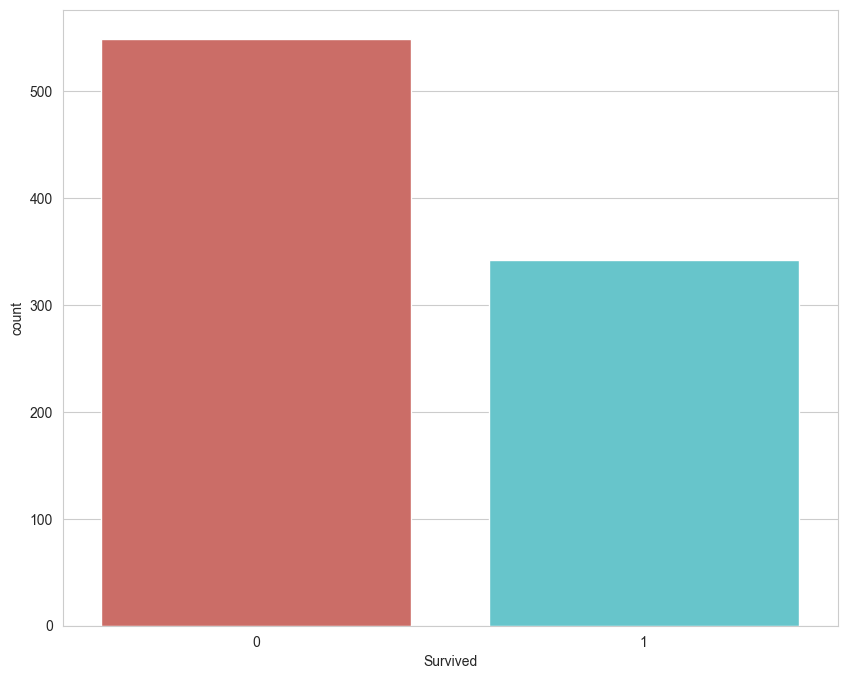

In [275]:
# Distribution of target class
sns.countplot(x='Survived',data=titanic, palette='hls');

In [276]:
# Missing values
titanic.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [277]:
titanic.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [278]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [279]:
titanic_data = titanic.drop(columns=['PassengerId','Name','Ticket','Cabin'], axis=1)
titanic_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Dropping missing values:

- So let's just go ahead and drop all the variables that aren't relevant for predicting survival. We should at least keep the following:

- Survived - Since this variable is our target it is obviously relevant.

- Pclass - Does a passenger's class on the boat affect their chance of survival?

- Sex - Could a passenger's gender impact their survival rate?

- Age - Does a person's age impact their survival rate?

- SibSp - Does the number of relatives on the boat (that are siblings or a spouse) affect a person's chance of survival? Could be...

- Parch - Does the number of relatives on the boat (that are children or parents) affect a person's chance of survival? Possible...

- Fare - Does the fare a person paid effect their chance of survival? Maybe - let's keep it.

- Embarked - Does a person's point of embarkation matter? It depends on how the boat was filled... Let's keep it.

- What about a person's name, ticket number, and passenger ID number? The passenger ID is a unique number for every passenger and therefore should not contain any useful information for our model. The features name and ticket number might contain helpful information but we would need some proper feature engineering to extract it. For now we will not consider those features for predicting the chance of survival. And as you recall, the cabin variable is almost all missing values, so we will just drop all of these.

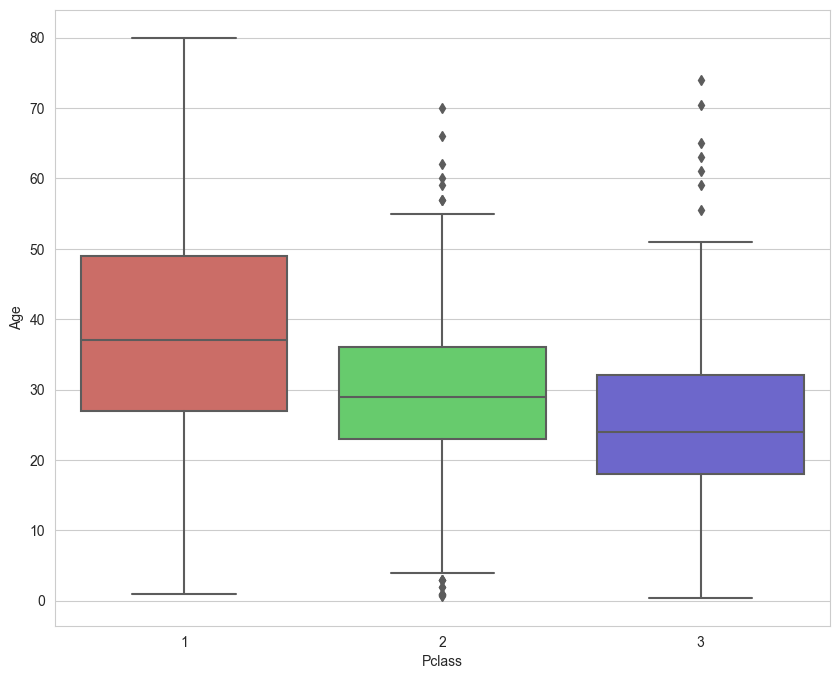

In [263]:
# Display age per class
sns.boxplot(x='Pclass', y='Age', data=titanic_data, palette='hls');

Speaking roughly, we could say that the younger a passenger is, the more likely it is for them to be in 3rd class. The older a passenger is, the more likely it is for them to be in 1st class. So there is a loose relationship between these variables. So, let's write a function that approximates a passengers age, based on their class. From the box plot, it looks like the median age of 1st class passengers is about 37, 2nd class passengers is 29, and 3rd class passengers is 24.

So let's write a function that finds each null value in the Age variable, and for each null, checks the value of the Pclass and assigns an age value according to the average age of passengers in that class.

In [280]:
# Drop rows with missing values in Embarkment column
titanic_data.dropna(inplace=True)
titanic_data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [ ]:
# Check for median age per class
titanic_data.groupby('Pclass').median()

In [282]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 50.1+ KB


In [283]:
def age_approx(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

In [284]:
# Replace missing values in age column
titanic_data['Age'] = titanic_data[['Age', 'Pclass']].apply(age_approx, axis=1)
titanic_data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [285]:
# Drop rows with missing values in Embarkment column
titanic_data.dropna(inplace=True)
titanic_data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [286]:
# One-hot-encode sex column
gender = pd.get_dummies(titanic_data['Sex'], dtype=int,drop_first=True)
gender.head()

,male
0,1
1,0
2,0
3,0
4,1


In [287]:
# One-hot-encode embarked column
embark_location = pd.get_dummies(titanic_data['Embarked'], dtype=int,drop_first=True)
embark_location.head()

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [288]:
# Drop original columns for sex and embarked
titanic_data.drop(['Sex', 'Embarked'],axis=1,inplace=True)
titanic_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [289]:
# Concatenate one-hot-encoded columns for sex and embarked 
titanic_dmy = pd.concat([titanic_data,gender,embark_location],axis=1)
titanic_dmy.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


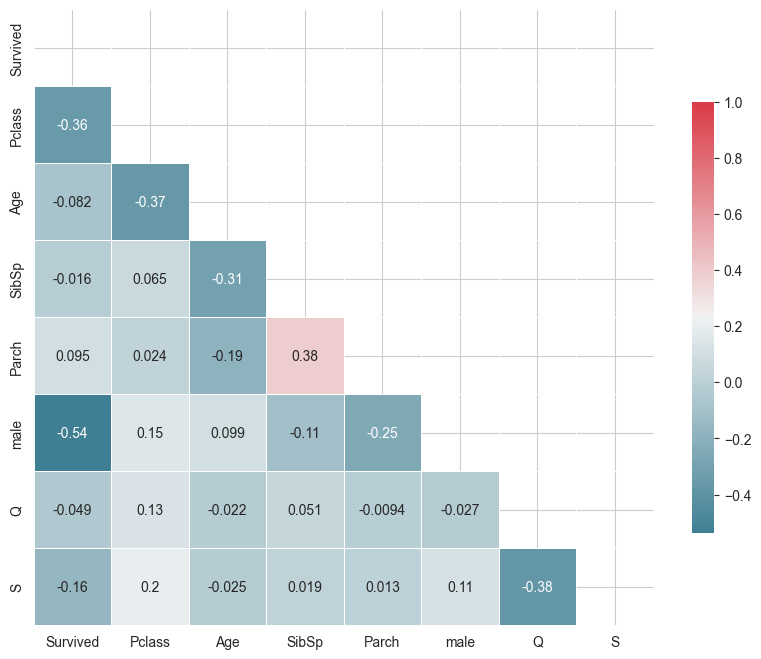

In [ ]:
# Compute correlations
correlations = titanic_dmy.corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(correlations)
mask[np.triu_indices_from(mask)] = True

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlations, mask=mask, cmap=cmap, vmax=1, annot=True,
            linewidths=.5, cbar_kws={"shrink": .7});

In [290]:
# Fare and Pclass are not independent of each other, so I am going to drop one of these. 
titanic_dmy.drop(['Fare'] ,axis=1,inplace=True)
titanic_dmy.head()

,Survived,Pclass,Age,SibSp,Parch,male,Q,S
0,0,3,22.0,1,0,1,0,1
1,1,1,38.0,1,0,0,0,0
2,1,3,26.0,0,0,0,0,1
3,1,1,35.0,1,0,0,0,1
4,0,3,35.0,0,0,1,0,1


In [291]:
# We have 6 predictive features that remain. The rule of thumb is 50 records per feature... 
# so we need to have at least 300 records in this dataset. Let's check again.
# Ok, we have 889 records so we are fine.
titanic_dmy.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Age       712 non-null    float64
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   male      712 non-null    int64  
 6   Q         712 non-null    int64  
 7   S         712 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 50.1 KB


In [292]:
# Define features and target variable
X = titanic_dmy.drop("Survived", axis=1)
y = titanic_dmy.iloc[:,0].values

# Train-test-split & Metric

Before we start modeling we have to split our data into a train and test set and define a metric. In this particular case it is hard to say that making more mistakes with regard to the false positives is worse than having more false negatives and vice versa. Therefore, we will choose a metric that takes precision and recall into account and evaluate our models using the f1-score.

In [293]:
# Split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state=25)

## Baseline Model
 * Before we start modeling we need to create a baseline model, which is basically an educated guess. From the correlation matrix above we can see that the gender is the feature with the highest (in our case negative) correlation to our target variable. Creating a countplot with the gender and survived feature shows also that the majority of the men did not survive, while most of the women survived. As a simple baseline model we could assume that your chance of survival is only related to your gender and whenever you are a man you will inevitably die while all women will survive. That's if course a very drastic view and not completely correct but we only want to create a "baseline" that our more sophisticated models have to beat.

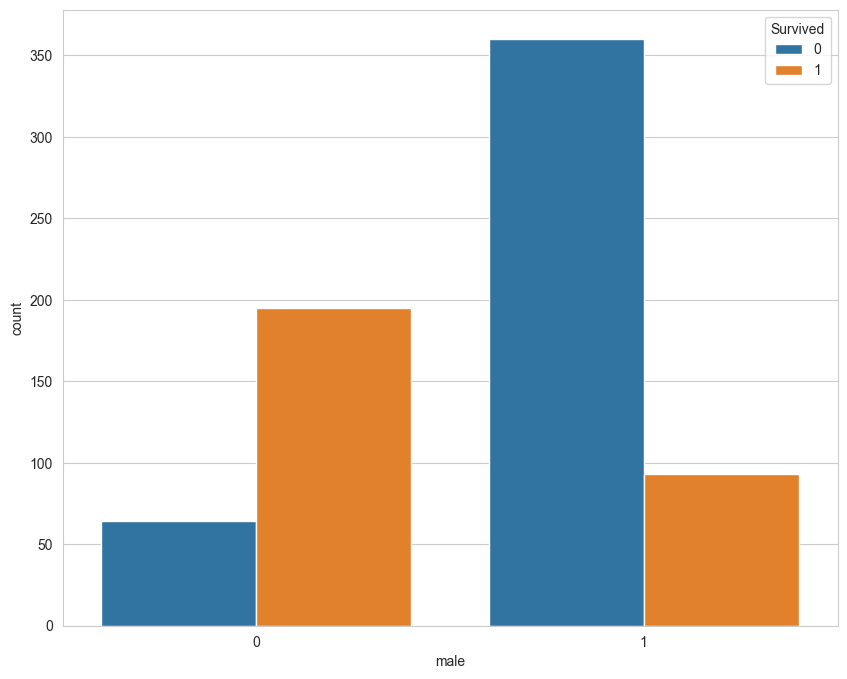

In [294]:
sns.countplot(x="male", data=titanic_dmy, hue="Survived");

In [295]:
# Defining baseline model
def baseline_model(df):
    y_pred = [0 if x == 1 else 1 for x in df.male]
    return y_pred

In [296]:
# Compute predictions with baseline model for test set
y_baseline_test = baseline_model(X_test)

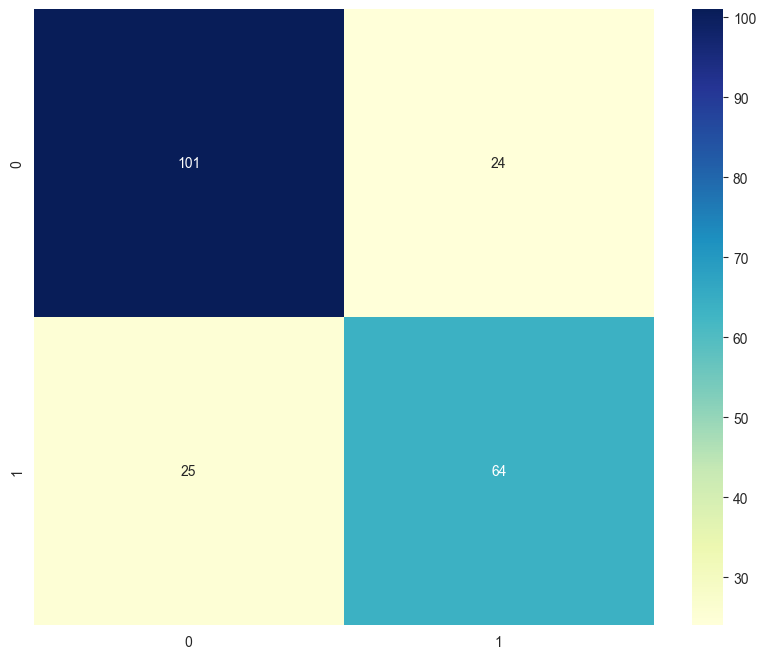

In [ ]:
# Plot confusion matrix for baseline model
cm = confusion_matrix(y_test, y_baseline_test)
sns.heatmap(cm, cmap="YlGnBu", annot=True, fmt='d');

In [297]:
# Calculate f1-score for baseline model
print("F1-score: ", f1_score(y_test, y_baseline_test).round(2))

F1-score:  0.72


Our baseline model manages to predict 135 respectively 69 people correctly. It misclassifies 29 instanced that actually belong to class 1 as being class 0 and 34 instances vice versa.

The computed f1-score is 0.69. Let's see if we can improve this with a logistic regression.



## Logistic Regression

In [298]:
# Instantiate model and fit it on train data
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [299]:
# Make predictions for test set
y_pred = logreg.predict(X_test)

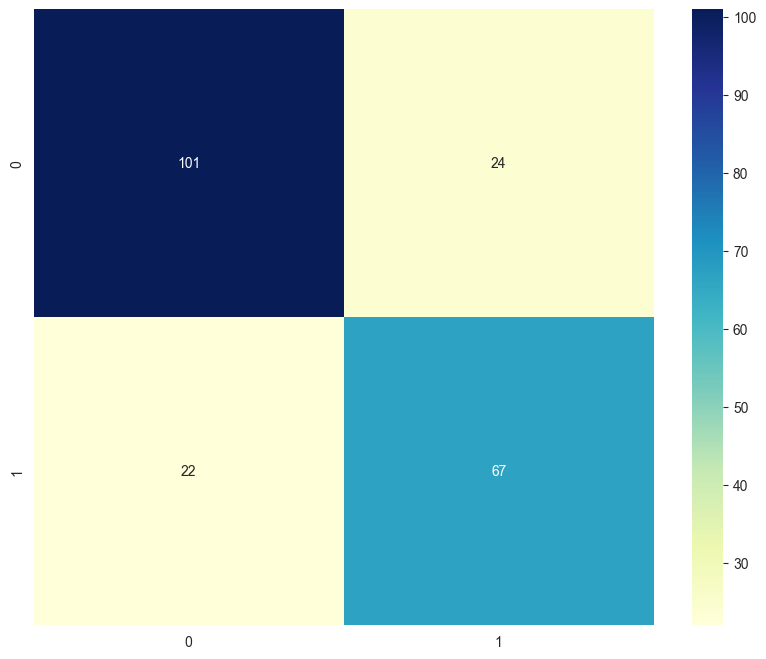

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, cmap="YlGnBu", annot=True, fmt='d');

In [300]:
# Calculate f1-score for baseline model
print("F1-score: ", f1_score(y_test, y_pred).round(2))

F1-score:  0.74


The confusion matrix shows that 135 and 73 are the number of correct predictions. 29 instances from class 0 where incorrectly classified as belonging to class 1. With regard to the false negatives, the instances that actually belong to class 1 but where classified as being class 0, our model improved a bit compared to the baseline.

Also the f1-score is with 0.71 slightly higher compared to the baseline model, but I would probably not call it a huge improvement. Seems that our choice of a baseline model was not that bad...

In [301]:
# Print classification report for more information
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81       125
           1       0.74      0.75      0.74        89

    accuracy                           0.79       214
   macro avg       0.78      0.78      0.78       214
weighted avg       0.79      0.79      0.79       214

